# Task 4: Session Refinement, Engagement, and Timing Analysis

Follow up on rating attribution task from last week.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GRAY, GREEN, ORANGE = '#3274A1', '#C9463D', '#888888', '#2ca02c', '#F5A623'

DATA_PATH = '../../data/ratings-enriched.parquet'

## 0. Load Data

In [2]:
df = pd.read_parquet(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Date range: {df["ratingCreatedAt"].min()} to {df["ratingCreatedAt"].max()}')
print(f'Unique raters:  {df["raterParticipantId"].nunique():,}')
print(f'Unique notes:   {df["noteId"].nunique():,}')
print(f'Unique tweets:  {df["ratedOnTweetId"].nunique():,}')
df.head(3)

Shape: (6499635, 13)
Columns: ['noteId', 'ratedOnTweetId', 'raterParticipantId', 'noteAuthorParticipantId', 'postCreatedAt', 'noteCreatedAt', 'ratingCreatedAt', 'helpfulnessLevel', 'fromNotification', 'in_session', 'post_interest', 'from_notification', 'in_swarm']
Date range: 2026-01-17 00:00:00.204000 to 2026-02-16 04:04:45.688000
Unique raters:  484,059
Unique notes:   114,204
Unique tweets:  84,316


,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,in_session,post_interest,from_notification,in_swarm
0,2016534713742061788,2016246745739546987,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,FD7979DE7F187DC14A4FDF8F5572424D060AA56E50AB30...,2026-01-27 20:27:38.894,2026-01-28 15:31:55.816,2026-01-28 20:47:22.321,HELPFUL,False,False,False,False,False
1,2017641230612451495,2017578816177111423,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2CE75633DDBFF074EE77E7DC582D7B557DC4D737E5FD81...,2026-01-31 12:40:49.235,2026-01-31 16:48:49.996,2026-01-31 17:21:23.365,HELPFUL,False,False,False,False,False
2,2018404224149717157,2018387895459983768,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,54F0002E8A4890D64140C45F5D108C9D76FDA829A157A0...,2026-02-02 18:15:48.768,2026-02-02 19:20:41.831,2026-02-02 22:44:01.605,HELPFUL,False,False,False,False,False


## 1. Tweet-Level Session Definition

Instead of looking at gaps between consecutive note ratings, compute gaps between a user's first rating on each tweet. This collapses multi-note visits to the same tweet into one event.

In [3]:
# Full frame — keep NaN deltas (first arrival per user) for session counting later
tweet_all = (
    df.groupby(['raterParticipantId', 'ratedOnTweetId'])['ratingCreatedAt']
    .min().reset_index()
    .rename(columns={'ratingCreatedAt': 'tweet_first_t'})
    .sort_values(['raterParticipantId', 'tweet_first_t'])
)
tweet_all['delta_sec'] = (
    tweet_all.groupby('raterParticipantId')['tweet_first_t']
    .diff().dt.total_seconds()
)

# Drop first-per-user rows for gap analysis
tweet_first = tweet_all.dropna(subset=['delta_sec']).copy()
tweet_first['log_delta'] = np.log(tweet_first['delta_sec'].clip(lower=1))

print(f'Tweet-level inter-arrival gaps: {len(tweet_first):,}')
print(tweet_first['delta_sec'].describe(percentiles=[.25, .5, .75, .9, .99]).round(1))

Tweet-level inter-arrival gaps: 3,904,370
count    3904370.0
mean      128544.3
std       249551.9
min            0.0
25%         2478.5
50%        35958.8
75%       131256.4
90%       353237.6
99%      1300080.2
max      2586889.1
Name: delta_sec, dtype: float64


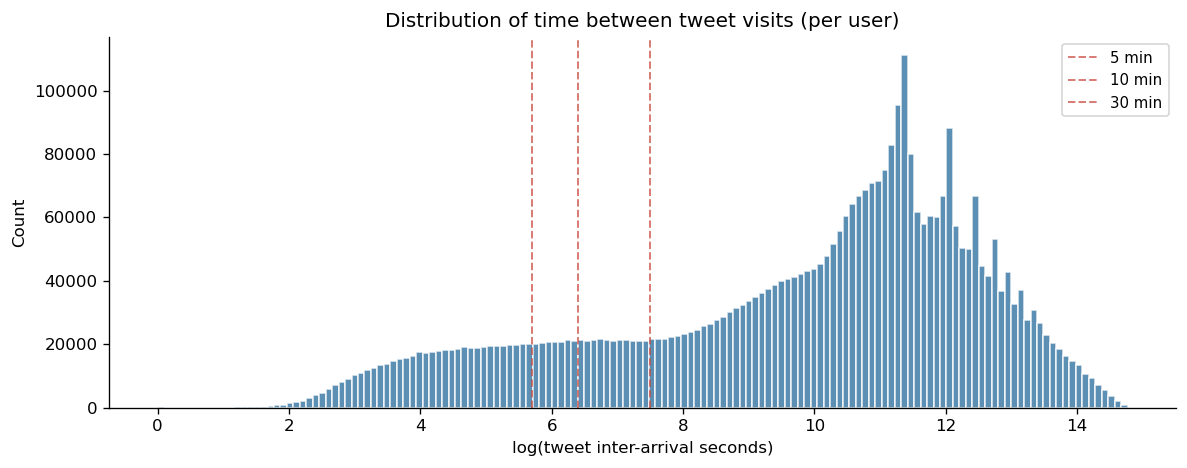

In [4]:
# Plot raw distribution first to find the natural break
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tweet_first['log_delta'], bins=150, color=BLUE, alpha=0.8, edgecolor='white')
ax.set_xlabel('log(tweet inter-arrival seconds)')
ax.set_ylabel('Count')
ax.set_title('Distribution of time between tweet visits (per user)')

for cutoff_sec, label in [(300, '5 min'), (600, '10 min'), (1800, '30 min')]:
    ax.axvline(np.log(cutoff_sec), color=RED, linestyle='--', alpha=0.7, linewidth=1.2, label=label)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('task4_tweet_arrival_dist.png', bbox_inches='tight')
plt.show()

In [5]:
# Cutoff chosen from the valley in the bimodal distribution above
TWEET_SESSION_GAP_SEC = 600  # 10 minutes

tweet_first['in_session_tweet'] = tweet_first['delta_sec'] <= TWEET_SESSION_GAP_SEC

# Mark session starts on the full frame for engagement counting
tweet_all['session_start'] = (
    tweet_all['delta_sec'].isna() |
    (tweet_all['delta_sec'] > TWEET_SESSION_GAP_SEC)
)

pct = 100 * tweet_first['in_session_tweet'].mean()
print(f'Tweet arrivals in session: {tweet_first["in_session_tweet"].sum():,}  ({pct:.1f}%)')
print(f'Tweet arrivals not in session: {(~tweet_first["in_session_tweet"]).sum():,}  ({100-pct:.1f}%)')

Tweet arrivals in session: 668,391  (17.1%)
Tweet arrivals not in session: 3,235,979  (82.9%)


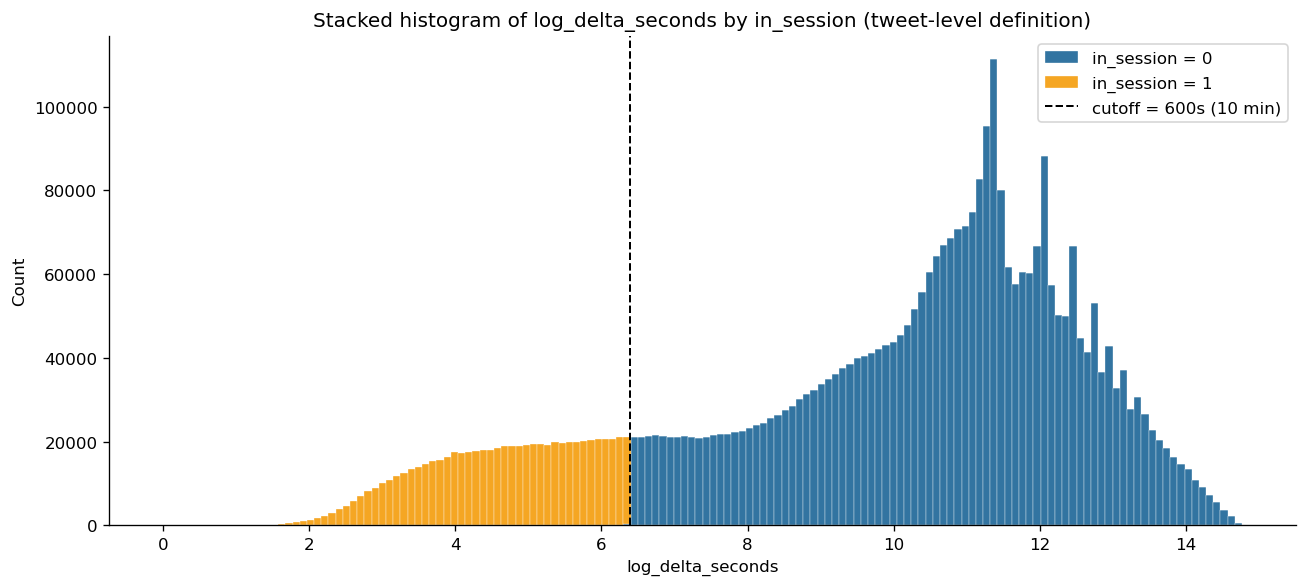

In [6]:
# Recreate Benedict's stacked histogram using tweet-level session definition
in_sess  = tweet_first.loc[ tweet_first['in_session_tweet'], 'log_delta'].values
out_sess = tweet_first.loc[~tweet_first['in_session_tweet'], 'log_delta'].values

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    [out_sess, in_sess],
    bins=150, stacked=True,
    color=[BLUE, ORANGE],
    label=['in_session = 0', 'in_session = 1'],
    edgecolor='white', linewidth=0.2
)
ax.axvline(np.log(TWEET_SESSION_GAP_SEC), color='black', linestyle='--',
           linewidth=1.2, label=f'cutoff = {TWEET_SESSION_GAP_SEC}s ({TWEET_SESSION_GAP_SEC//60} min)')
ax.set_xlabel('log_delta_seconds')
ax.set_ylabel('Count')
ax.set_title('Stacked histogram of log_delta_seconds by in_session (tweet-level definition)')
ax.legend()
plt.tight_layout()
plt.savefig('task4_tweet_session_stacked.png', bbox_inches='tight')
plt.show()

## 2. Engagement Classification

Per user per week: count number of sessions. Use that distribution to set engagement level cutoffs.

In [7]:
tweet_all['week'] = tweet_all['tweet_first_t'].dt.isocalendar().week

user_week = (
    tweet_all.groupby(['raterParticipantId', 'week'])
    .agg(
        n_ratings=('tweet_first_t', 'count'),
        n_sessions=('session_start', 'sum')
    ).reset_index()
)

print(f'User-week rows: {len(user_week):,}')
print('\nSessions per user-week:')
print(user_week['n_sessions'].describe(percentiles=[.25, .5, .75, .9, .95]).round(1))
print('\nSession count distribution (top 15):')
print(user_week['n_sessions'].value_counts().sort_index().head(15))

User-week rows: 1,173,766

Sessions per user-week:
count    1173766.0
mean           3.2
std            4.7
min            0.0
25%            1.0
50%            2.0
75%            3.0
90%            7.0
95%           11.0
max          176.0
Name: n_sessions, dtype: float64

Session count distribution (top 15):
n_sessions
0         40
1     574938
2     211736
3     110752
4      67948
5      45950
6      31993
7      24023
8      18355
9      14271
10     11510
11      9277
12      7502
13      6404
14      5192
Name: count, dtype: int64


Engagement distribution:
  not       :      40  (0.0%)
  barely    : 574,938  (49.0%)
  somewhat  : 390,436  (33.3%)
  very      : 208,352  (17.8%)


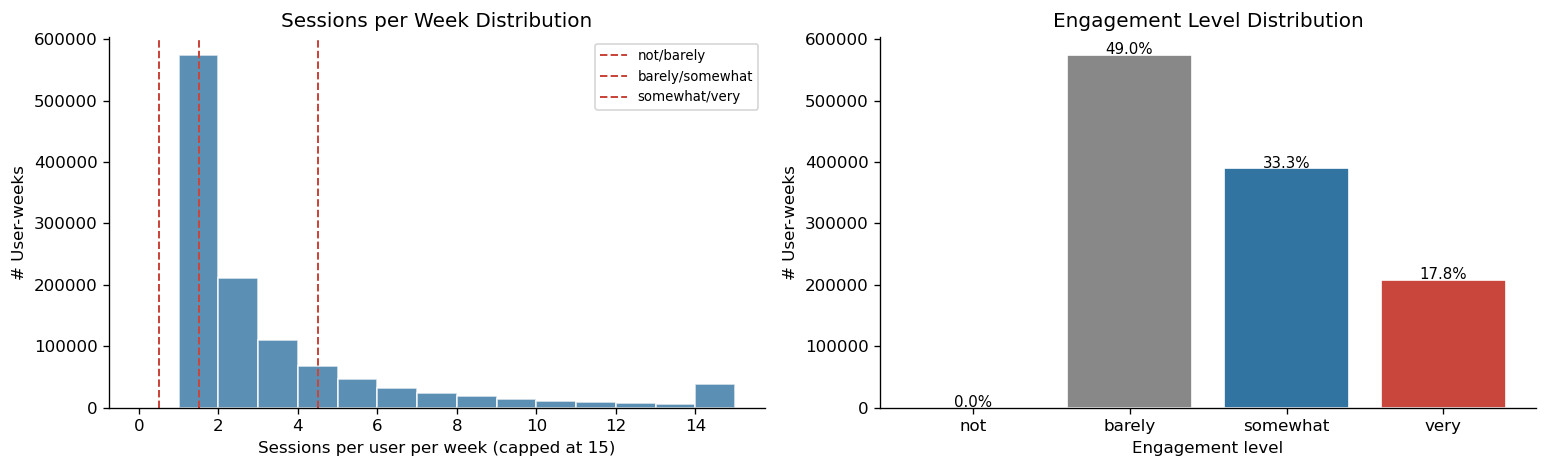

In [8]:
# Cutoffs from the distribution above
def engagement_level(n_sessions):
    if n_sessions == 0:
        return 'not'
    elif n_sessions == 1:
        return 'barely'
    elif n_sessions <= 4:
        return 'somewhat'
    else:
        return 'very'

user_week['engagement'] = user_week['n_sessions'].apply(engagement_level)

eng_order = ['not', 'barely', 'somewhat', 'very']
eng_counts = user_week['engagement'].value_counts()
print('Engagement distribution:')
for lvl in eng_order:
    n = eng_counts.get(lvl, 0)
    print(f'  {lvl:<10}: {n:>7,}  ({100*n/len(user_week):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(user_week['n_sessions'].clip(upper=15), bins=15, color=BLUE, alpha=0.8, edgecolor='white')
for cutoff, label in [(1, 'not/barely'), (2, 'barely/somewhat'), (5, 'somewhat/very')]:
    ax.axvline(cutoff - 0.5, color=RED, linestyle='--', linewidth=1.2, label=label)
ax.set_xlabel('Sessions per user per week (capped at 15)')
ax.set_ylabel('# User-weeks')
ax.set_title('Sessions per Week Distribution')
ax.legend(fontsize=8)

ax = axes[1]
colors_eng = [GREEN, GRAY, BLUE, RED]
counts = [eng_counts.get(lvl, 0) for lvl in eng_order]
bars = ax.bar(eng_order, counts, color=colors_eng, edgecolor='white')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{100*cnt/len(user_week):.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Engagement level')
ax.set_ylabel('# User-weeks')
ax.set_title('Engagement Level Distribution')

plt.tight_layout()
plt.savefig('task4_engagement.png', bbox_inches='tight')
plt.show()

## 3. Regularity Classification

Per user: how many unique weeks did they contribute? Dataset spans ~5 weeks.

Weeks in dataset: 6  [3, 4, 5, 6, 7, 8]

Unique weeks per user:
unique_weeks
1    186577
2    100357
3     70871
4     64457
5     54748
6      7049
Name: count, dtype: int64

Regularity distribution:
  irregular           : 186,577  (38.5%)
  somewhat regular    : 171,228  (35.4%)
  regular             : 126,254  (26.1%)


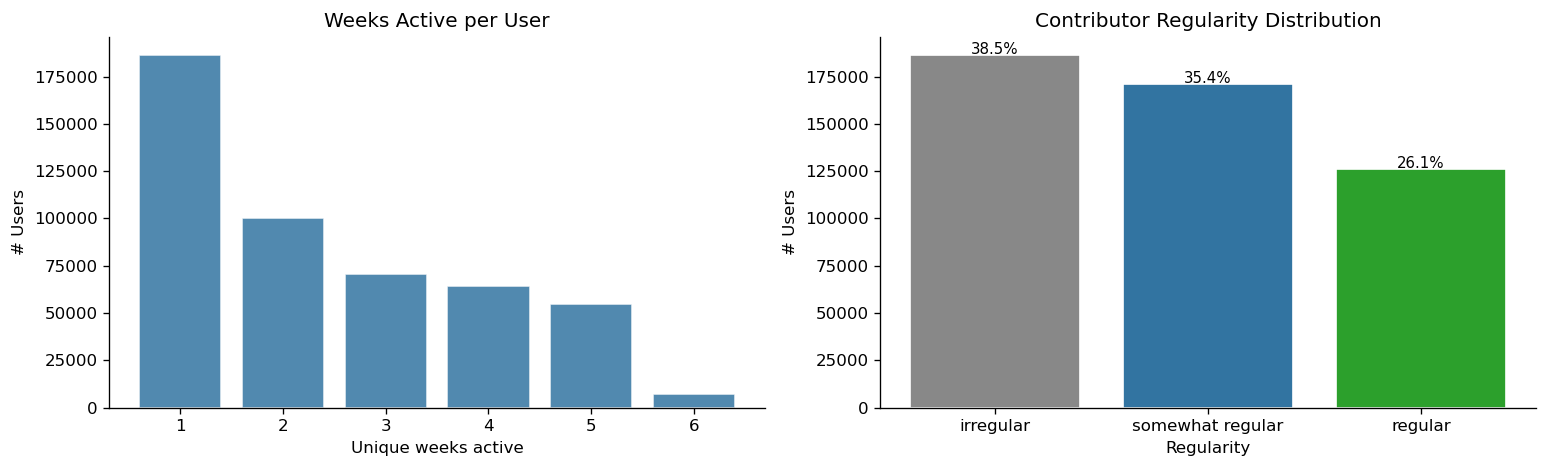

In [9]:
user_weeks_active = (
    user_week.groupby('raterParticipantId')['week']
    .nunique().reset_index(name='unique_weeks')
)

total_weeks = user_week['week'].nunique()
print(f'Weeks in dataset: {total_weeks}  {sorted(user_week["week"].unique())}')
print('\nUnique weeks per user:')
print(user_weeks_active['unique_weeks'].value_counts().sort_index())

def regularity(n_weeks):
    if n_weeks <= 1:
        return 'irregular'
    elif n_weeks <= 3:
        return 'somewhat regular'
    else:
        return 'regular'

user_weeks_active['regularity'] = user_weeks_active['unique_weeks'].apply(regularity)

reg_order = ['irregular', 'somewhat regular', 'regular']
reg_counts = user_weeks_active['regularity'].value_counts()
print('\nRegularity distribution:')
for lvl in reg_order:
    n = reg_counts.get(lvl, 0)
    print(f'  {lvl:<20}: {n:>7,}  ({100*n/len(user_weeks_active):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
vc = user_weeks_active['unique_weeks'].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=BLUE, edgecolor='white', alpha=0.85)
ax.set_xlabel('Unique weeks active')
ax.set_ylabel('# Users')
ax.set_title('Weeks Active per User')

ax = axes[1]
counts_r = [reg_counts.get(lvl, 0) for lvl in reg_order]
bars = ax.bar(reg_order, counts_r, color=[GRAY, BLUE, GREEN], edgecolor='white')
for bar, cnt in zip(bars, counts_r):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{100*cnt/len(user_weeks_active):.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Regularity')
ax.set_ylabel('# Users')
ax.set_title('Contributor Regularity Distribution')

plt.tight_layout()
plt.savefig('task4_regularity.png', bbox_inches='tight')
plt.show()

## 4. Note-Level Inter-Rating Timing

Recreate Benedict's plot but using time between consecutive ratings on a given note, rather than a given user.

In [10]:
df_note = df.sort_values(['noteId', 'ratingCreatedAt']).copy()

df_note['note_delta_sec'] = (
    df_note.groupby('noteId')['ratingCreatedAt']
    .diff().dt.total_seconds()
)

note_gaps = df_note.dropna(subset=['note_delta_sec']).copy()
note_gaps['log1p_note_delta'] = np.log1p(note_gaps['note_delta_sec'])

print(f'Note-level gaps: {len(note_gaps):,}')
print(note_gaps['note_delta_sec'].describe(percentiles=[.25, .5, .75, .9, .99]).round(1))

Note-level gaps: 6,385,431
count    6385431.0
mean        4469.1
std        47162.4
min            0.0
25%           40.6
50%          168.6
75%          691.5
90%         2730.0
99%        67583.0
max      2556029.7
Name: note_delta_sec, dtype: float64


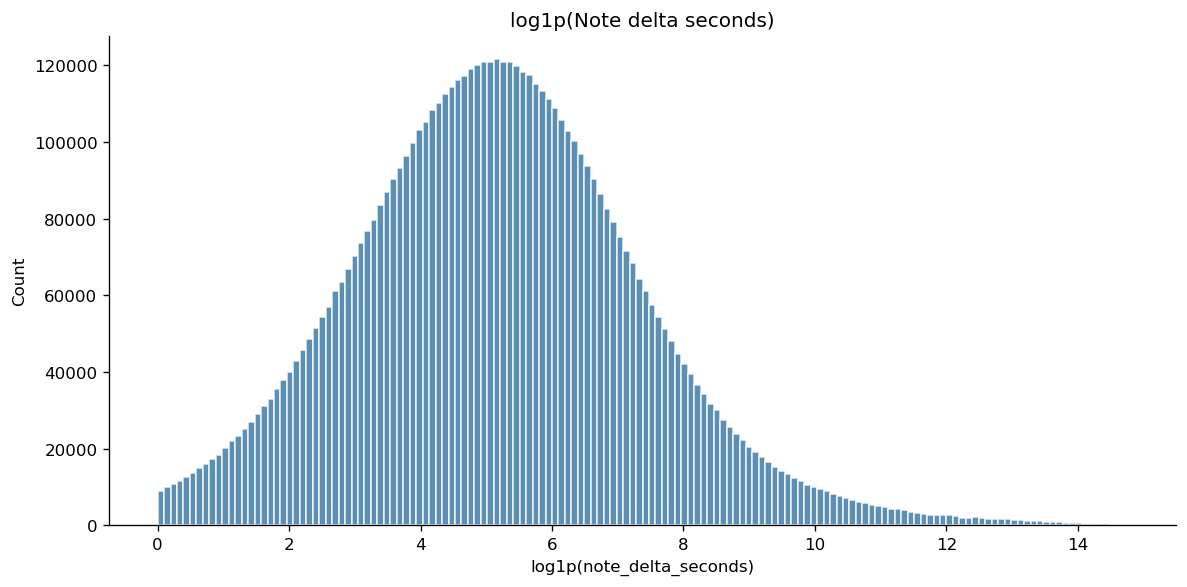

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(note_gaps['log1p_note_delta'], bins=150, color=BLUE, alpha=0.8, edgecolor='white')
ax.set_xlabel('log1p(note_delta_seconds)')
ax.set_ylabel('Count')
ax.set_title('log1p(Note delta seconds)')
plt.tight_layout()
plt.savefig('task4_note_timing.png', bbox_inches='tight')
plt.show()

## 5. Short-Burst Raters

Identify users who contributed ratings less than 7 seconds after the previous rating on the same note, and check whether they are a distinct subpopulation.

In [12]:
SHORT_BURST_SEC = 7

short_burst_ratings = note_gaps[note_gaps['note_delta_sec'] < SHORT_BURST_SEC]
short_burst_users   = set(short_burst_ratings['raterParticipantId'].unique())

print(f'Ratings with note gap < {SHORT_BURST_SEC}s: {len(short_burst_ratings):,}  ({100*len(short_burst_ratings)/len(note_gaps):.2f}% of gapped ratings)')
print(f'Unique short-burst users: {len(short_burst_users):,}  ({100*len(short_burst_users)/df["raterParticipantId"].nunique():.1f}% of all raters)')

user_total_ratings = df.groupby('raterParticipantId').size().rename('total_ratings')
short_df = pd.DataFrame({'is_short_burst': True}, index=list(short_burst_users))
short_df.index.name = 'raterParticipantId'
comparison = user_total_ratings.to_frame().join(short_df)
comparison['is_short_burst'] = comparison['is_short_burst'].fillna(False)

print('\nRatings per user -- short-burst vs. normal:')
print(comparison.groupby('is_short_burst')['total_ratings'].describe().round(1))

Ratings with note gap < 7s: 465,415  (7.29% of gapped ratings)
Unique short-burst users: 157,873  (32.6% of all raters)

Ratings per user -- short-burst vs. normal:
                   count  mean   std  min  25%   50%   75%     max
is_short_burst                                                    
False           326186.0   4.4   6.5  1.0  1.0   2.0   5.0   368.0
True            157873.0  32.0  66.7  1.0  5.0  13.0  34.0  4028.0


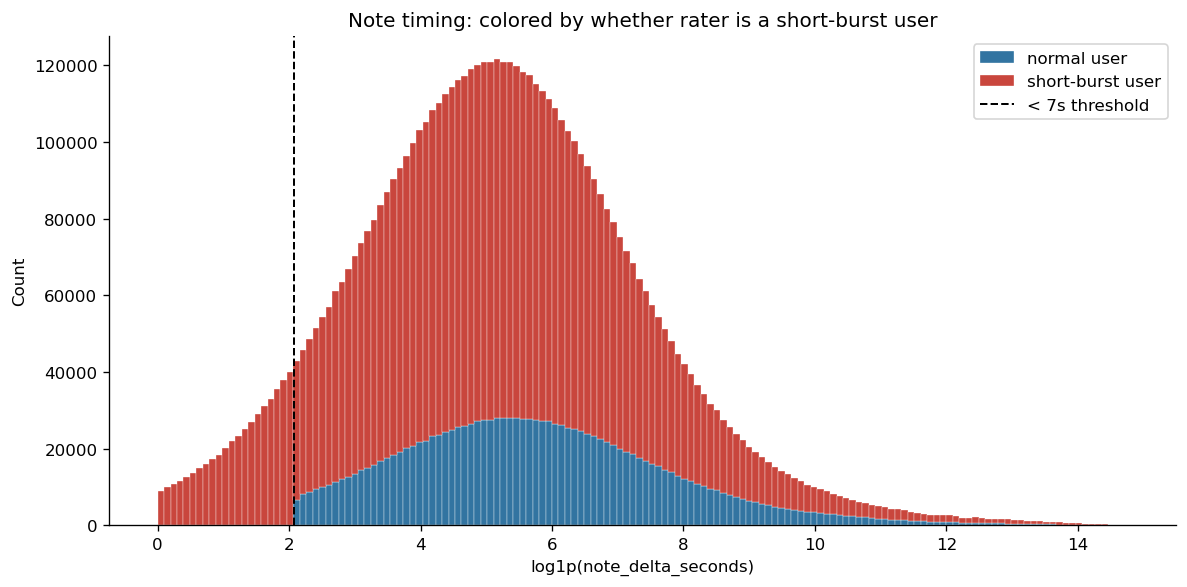

In [13]:
note_gaps['is_short_burst_user'] = note_gaps['raterParticipantId'].isin(short_burst_users)

sb_true  = note_gaps.loc[ note_gaps['is_short_burst_user'], 'log1p_note_delta'].values
sb_false = note_gaps.loc[~note_gaps['is_short_burst_user'], 'log1p_note_delta'].values

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    [sb_false, sb_true],
    bins=150, stacked=True,
    color=[BLUE, RED],
    label=['normal user', 'short-burst user'],
    edgecolor='white', linewidth=0.2
)
ax.axvline(np.log1p(SHORT_BURST_SEC), color='black', linestyle='--',
           linewidth=1.2, label=f'< {SHORT_BURST_SEC}s threshold')
ax.set_xlabel('log1p(note_delta_seconds)')
ax.set_ylabel('Count')
ax.set_title('Note timing: colored by whether rater is a short-burst user')
ax.legend()
plt.tight_layout()
plt.savefig('task4_short_burst.png', bbox_inches='tight')
plt.show()

## 6. User Trajectory Analysis

How rater, writer, and requester behavior changes over users' lifetimes.

In [14]:
RAT  = pd.read_parquet('../../data/sample_user_rating_traj.parquet')
NOTE = pd.read_parquet('../../data/sample_user_note_traj.parquet')
REQ  = pd.read_parquet('../../data/sample_user_request_traj.parquet')

print(f'Raters:     {RAT["raterParticipantId"].nunique():,} users, {len(RAT):,} rows, userMonth 0-{RAT["userMonth"].max()}')
print(f'Writers:    {NOTE["noteAuthorParticipantId"].nunique():,} users, {len(NOTE):,} rows, userMonth 0-{NOTE["userMonth"].max()}')
print(f'Requesters: {REQ["requesterParticipantId"].nunique():,} users, {len(REQ):,} rows, userMonth 0-{REQ["userMonth"].max()}')

Raters:     5,900 users, 69,249 rows, userMonth 0-60
Writers:    1,360 users, 4,191 rows, userMonth 0-52
Requesters: 15,439 users, 25,120 rows, userMonth 0-59


In [15]:
MAX_MONTH = 36
SAMPLE_N  = 100
RNG       = np.random.default_rng(42)

def sample_users(df, uid_col, min_months=3):
    eligible = df.groupby(uid_col).filter(lambda x: len(x) >= min_months)[uid_col].unique()
    return RNG.choice(eligible, min(SAMPLE_N, len(eligible)), replace=False)

def indiv_plot(ax, df, uid_col, sampled, ycol, color, label=None):
    sub = df[df[uid_col].isin(sampled) & (df['userMonth'] <= MAX_MONTH)]
    for uid in sampled:
        u = sub[sub[uid_col] == uid].sort_values('userMonth')
        ax.plot(u['userMonth'], u[ycol], color=color, alpha=0.06, linewidth=0.7)
    med = df[df['userMonth'] <= MAX_MONTH].groupby('userMonth')[ycol].median()
    ax.plot(med.index, med.values, color=color, linewidth=2.5, label=label or ycol)

def dist_plot(ax, df, ycol, color, label=None):
    sub = df[df['userMonth'] <= MAX_MONTH].dropna(subset=[ycol])
    gp  = sub.groupby('userMonth')[ycol]
    med = gp.median()
    ax.fill_between(med.index, gp.quantile(0.25), gp.quantile(0.75), color=color, alpha=0.22)
    ax.plot(med.index, med.values, color=color, linewidth=2, label=label)
    ax.set_xlabel('User month')

### Rater — Note Factor of Helpful vs. Not-Helpful Ratings

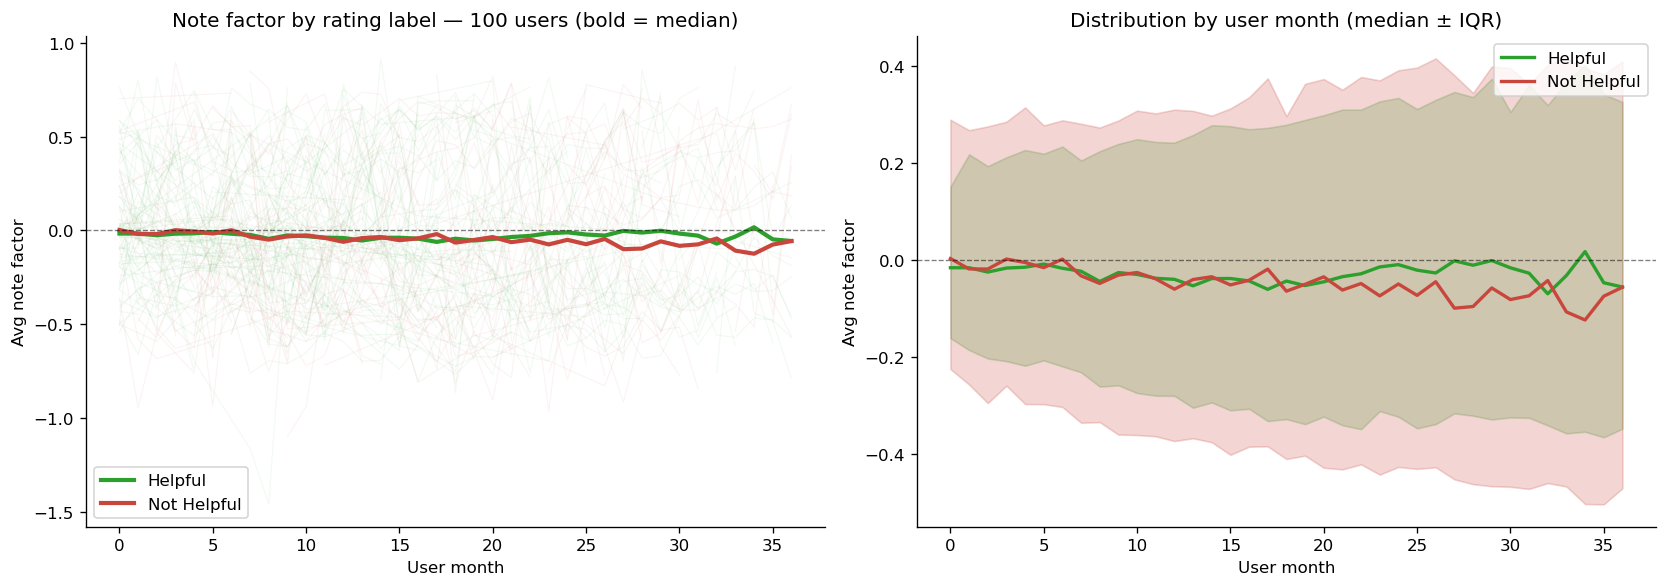

In [16]:
sampled_raters = sample_users(RAT, 'raterParticipantId')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
indiv_plot(ax, RAT, 'raterParticipantId', sampled_raters, 'avgHelpfulFactor',    GREEN, 'Helpful')
indiv_plot(ax, RAT, 'raterParticipantId', sampled_raters, 'avgNotHelpfulFactor', RED,   'Not Helpful')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('User month')
ax.set_ylabel('Avg note factor')
ax.set_title(f'Note factor by rating label — {SAMPLE_N} users (bold = median)')
ax.legend()

ax = axes[1]
dist_plot(ax, RAT, 'avgHelpfulFactor',    GREEN, label='Helpful')
dist_plot(ax, RAT, 'avgNotHelpfulFactor', RED,   label='Not Helpful')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Avg note factor')
ax.set_title('Distribution by user month (median ± IQR)')
ax.legend()

plt.tight_layout()
plt.savefig('task4_rater_factor.png', bbox_inches='tight')
plt.show()

### Rater — Counts of Pos/Neg Factor Notes Rated Helpful vs. Not-Helpful

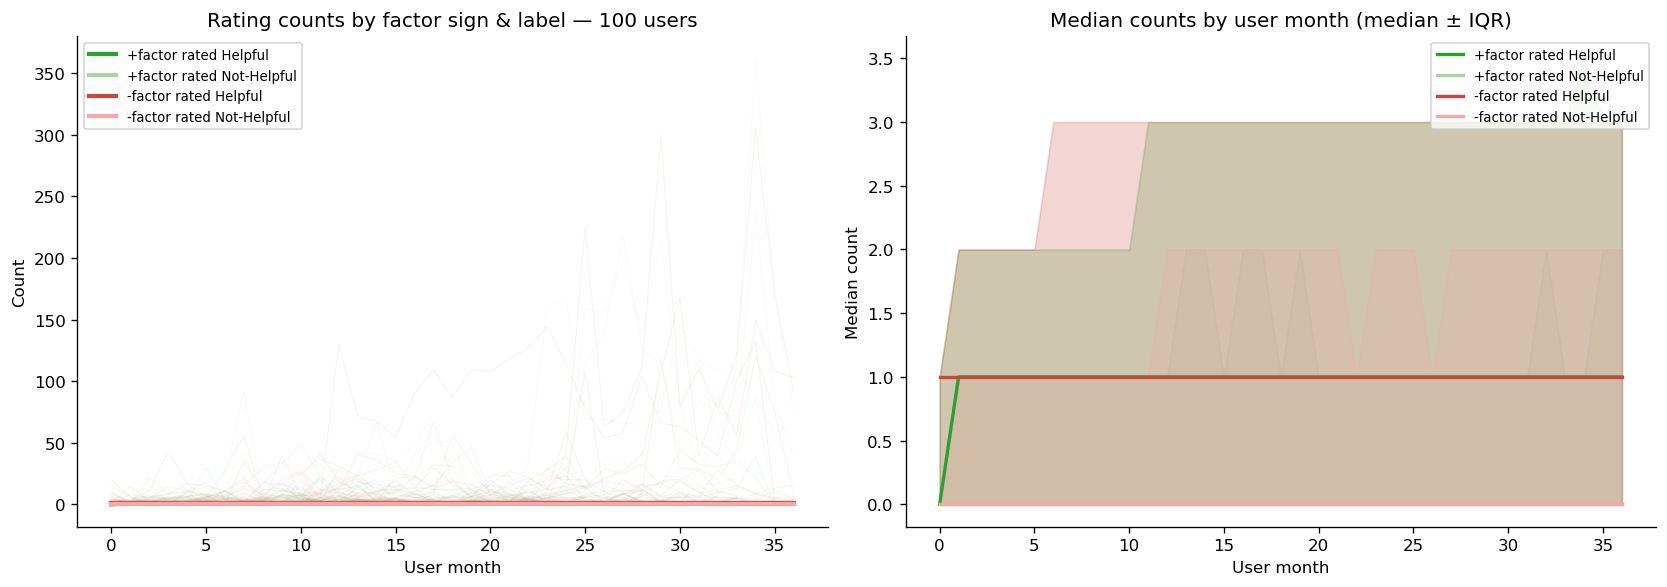

In [17]:
factor_cols   = ['posFactorRatedHelpful', 'posFactorRatedNotHelpful',
                 'negFactorRatedHelpful', 'negFactorRatedNotHelpful']
factor_colors = [GREEN, '#a8d5a2', RED, '#f5a8a8']
factor_labels = ['+factor rated Helpful', '+factor rated Not-Helpful',
                 '-factor rated Helpful', '-factor rated Not-Helpful']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for col, color, label in zip(factor_cols, factor_colors, factor_labels):
    indiv_plot(ax, RAT, 'raterParticipantId', sampled_raters, col, color, label)
ax.set_xlabel('User month')
ax.set_ylabel('Count')
ax.set_title(f'Rating counts by factor sign & label — {SAMPLE_N} users')
ax.legend(fontsize=8)

ax = axes[1]
for col, color, label in zip(factor_cols, factor_colors, factor_labels):
    dist_plot(ax, RAT, col, color, label=label)
ax.set_ylabel('Median count')
ax.set_title('Median counts by user month (median ± IQR)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('task4_rater_factor_counts.png', bbox_inches='tight')
plt.show()

### Rater — Overall Accuracy Over Time

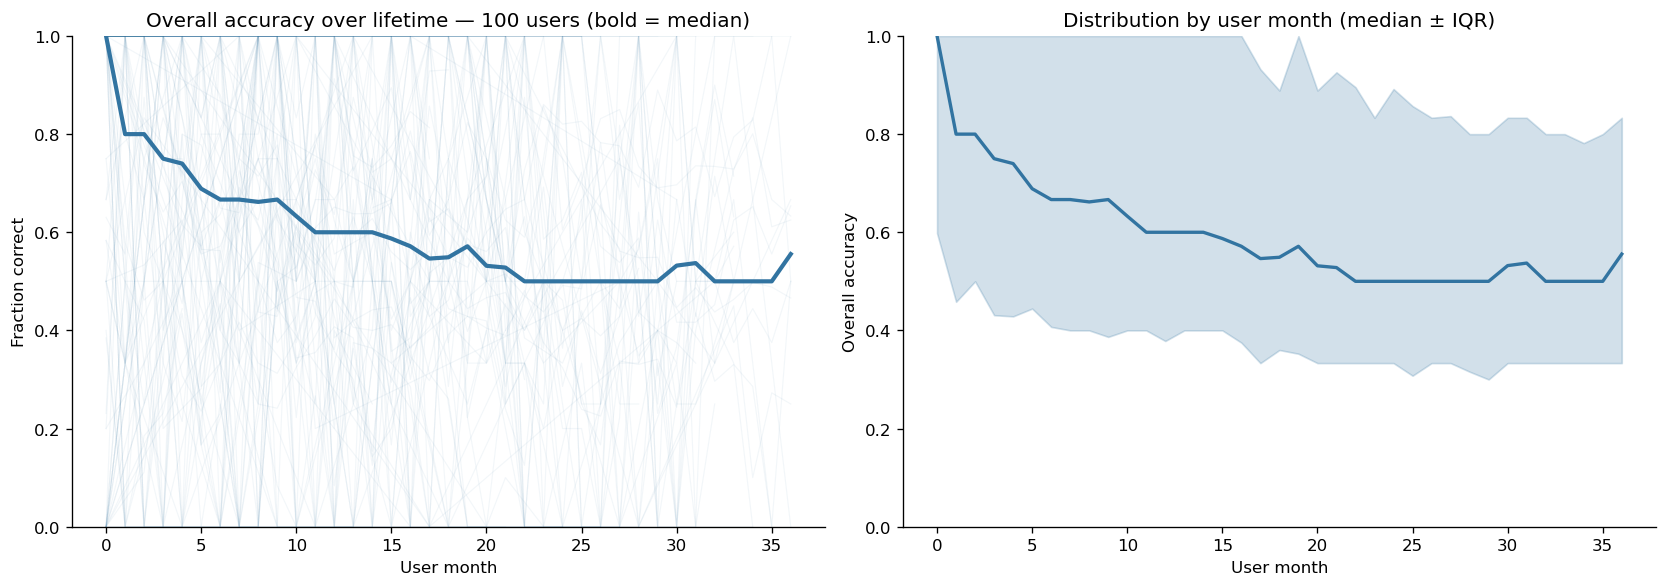

Overall accuracy by user month (median):
userMonth
0     1.000
1     0.800
2     0.800
3     0.750
4     0.740
5     0.689
6     0.667
7     0.667
8     0.662
9     0.667
10    0.633
11    0.600
12    0.600
13    0.600
14    0.600
15    0.587
16    0.571
17    0.546
18    0.549
19    0.571
20    0.532
21    0.528
22    0.500
23    0.500
24    0.500
25    0.500
26    0.500
27    0.500
28    0.500
29    0.500
30    0.532
31    0.537
32    0.500
33    0.500
34    0.500
35    0.500
36    0.556


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
indiv_plot(ax, RAT, 'raterParticipantId', sampled_raters, 'overallAccuracy', BLUE, 'Overall accuracy')
ax.set_xlabel('User month')
ax.set_ylabel('Fraction correct')
ax.set_ylim(0, 1)
ax.set_title(f'Overall accuracy over lifetime — {SAMPLE_N} users (bold = median)')

ax = axes[1]
dist_plot(ax, RAT, 'overallAccuracy', BLUE)
ax.set_ylabel('Overall accuracy')
ax.set_ylim(0, 1)
ax.set_title('Distribution by user month (median ± IQR)')

plt.tight_layout()
plt.savefig('task4_rater_accuracy.png', bbox_inches='tight')
plt.show()

sub = RAT[RAT['userMonth'] <= MAX_MONTH].dropna(subset=['overallAccuracy'])
print('Overall accuracy by user month (median):')
print(sub.groupby('userMonth')['overallAccuracy'].median().round(3).to_string())

### Rater — Note Intercept of Helpful vs. Not-Helpful Ratings

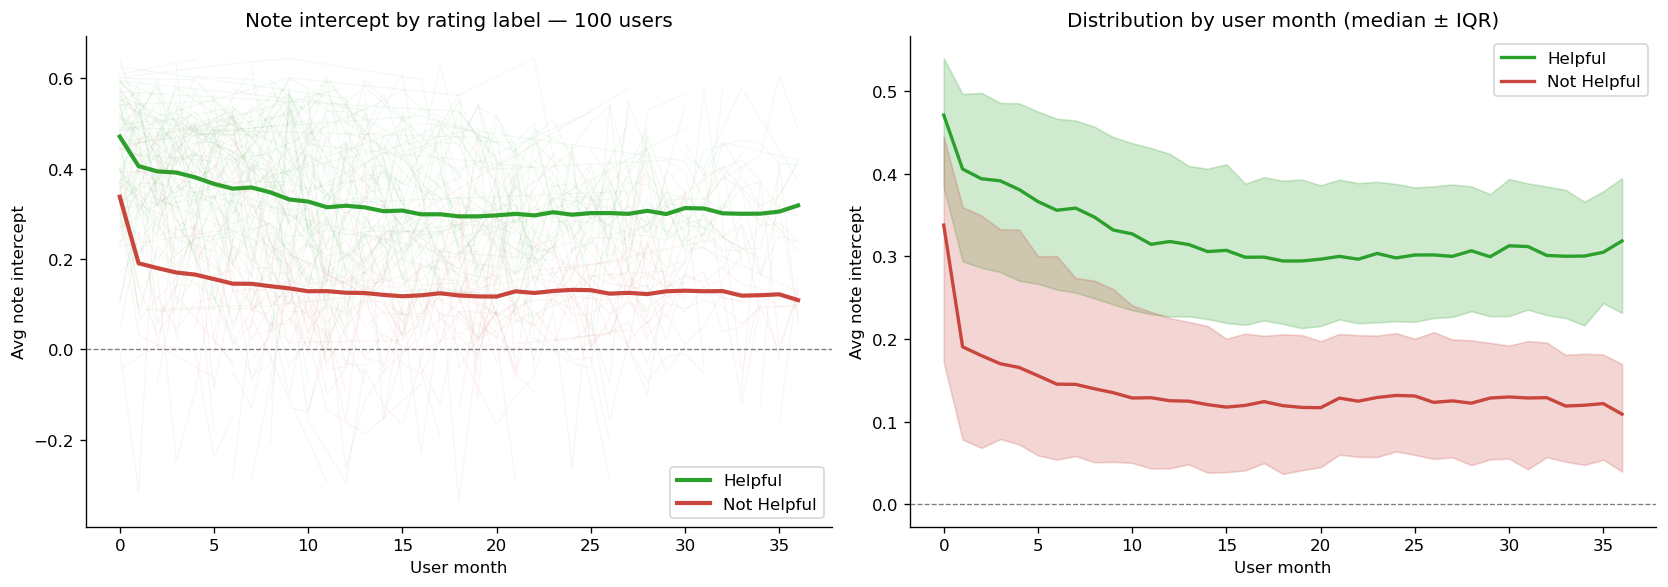

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
indiv_plot(ax, RAT, 'raterParticipantId', sampled_raters, 'avgHelpfulIntercept',    GREEN, 'Helpful')
indiv_plot(ax, RAT, 'raterParticipantId', sampled_raters, 'avgNotHelpfulIntercept', RED,   'Not Helpful')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('User month')
ax.set_ylabel('Avg note intercept')
ax.set_title(f'Note intercept by rating label — {SAMPLE_N} users')
ax.legend()

ax = axes[1]
dist_plot(ax, RAT, 'avgHelpfulIntercept',    GREEN, label='Helpful')
dist_plot(ax, RAT, 'avgNotHelpfulIntercept', RED,   label='Not Helpful')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Avg note intercept')
ax.set_title('Distribution by user month (median ± IQR)')
ax.legend()

plt.tight_layout()
plt.savefig('task4_rater_intercept.png', bbox_inches='tight')
plt.show()

### Writer — Avg Note Factor and Intercept Over Time

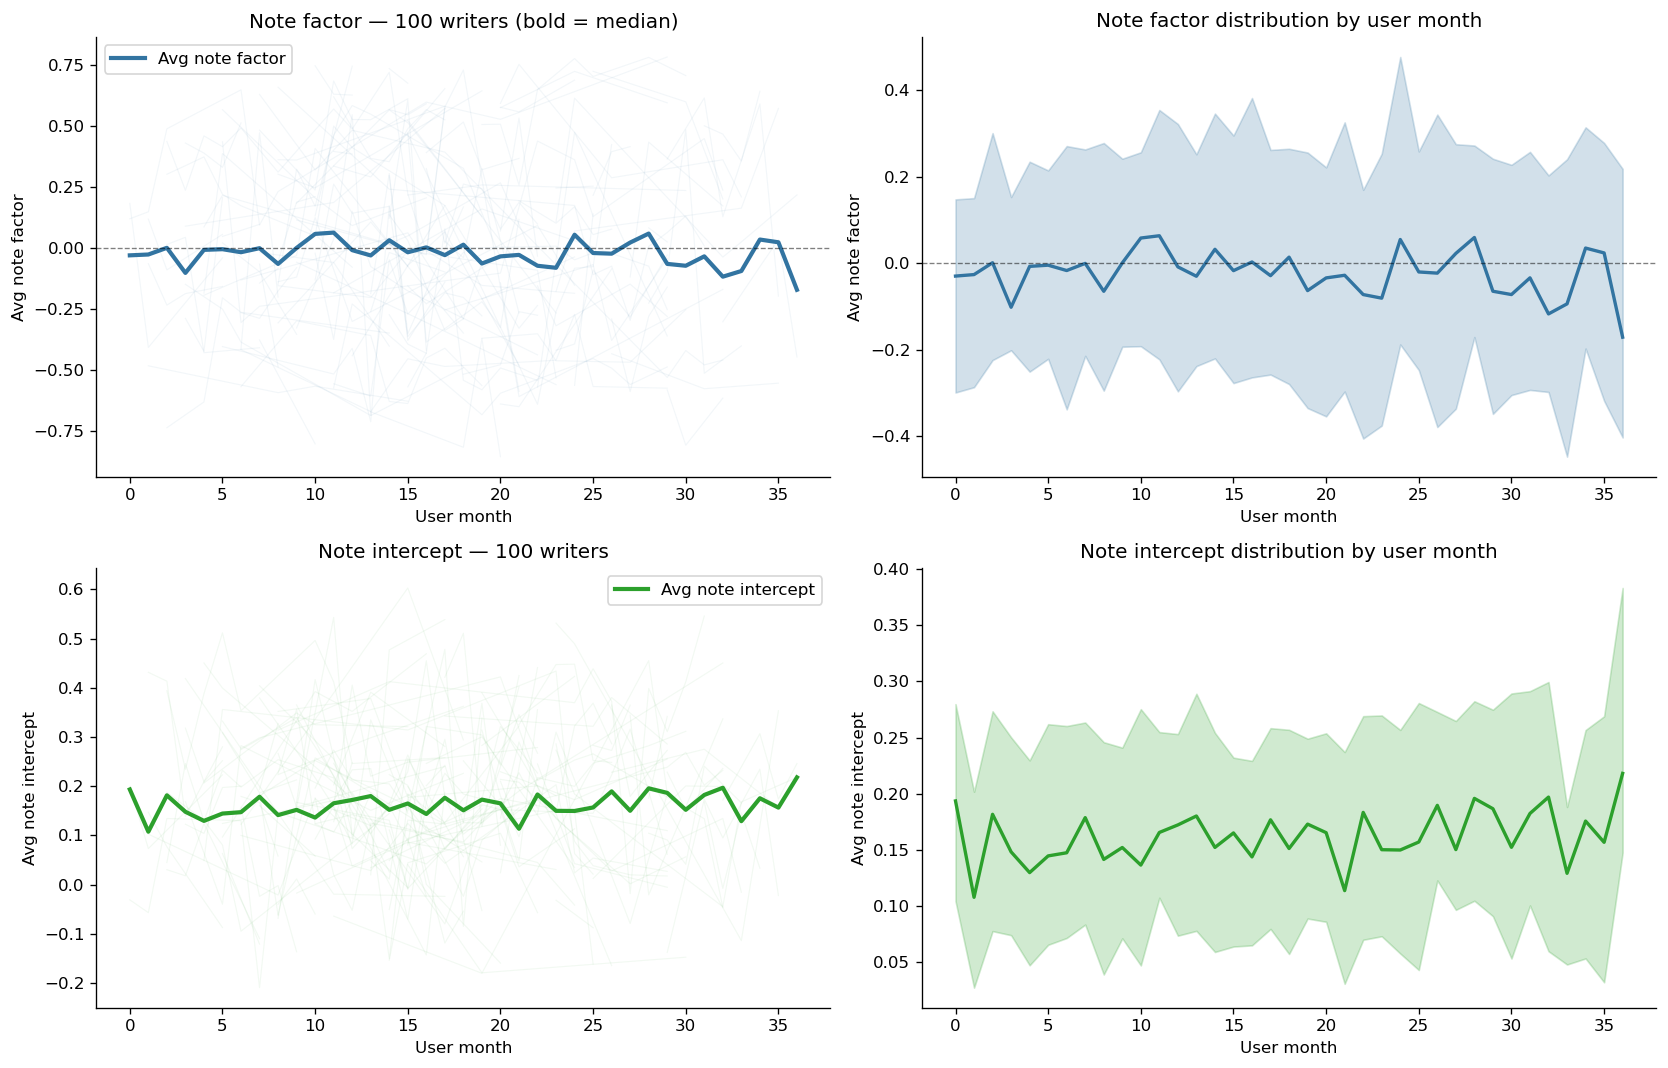

In [20]:
sampled_writers = sample_users(NOTE, 'noteAuthorParticipantId')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
indiv_plot(ax, NOTE, 'noteAuthorParticipantId', sampled_writers, 'avgNoteFactor', BLUE, 'Avg note factor')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('User month')
ax.set_ylabel('Avg note factor')
ax.set_title(f'Note factor — {SAMPLE_N} writers (bold = median)')
ax.legend()

ax = axes[0, 1]
dist_plot(ax, NOTE, 'avgNoteFactor', BLUE)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Avg note factor')
ax.set_title('Note factor distribution by user month')

ax = axes[1, 0]
indiv_plot(ax, NOTE, 'noteAuthorParticipantId', sampled_writers, 'avgNoteIntercept', GREEN, 'Avg note intercept')
ax.set_xlabel('User month')
ax.set_ylabel('Avg note intercept')
ax.set_title(f'Note intercept — {SAMPLE_N} writers')
ax.legend()

ax = axes[1, 1]
dist_plot(ax, NOTE, 'avgNoteIntercept', GREEN)
ax.set_ylabel('Avg note intercept')
ax.set_title('Note intercept distribution by user month')

plt.tight_layout()
plt.savefig('task4_writer_factor_intercept.png', bbox_inches='tight')
plt.show()

### Writer — CRH Notes Over Time

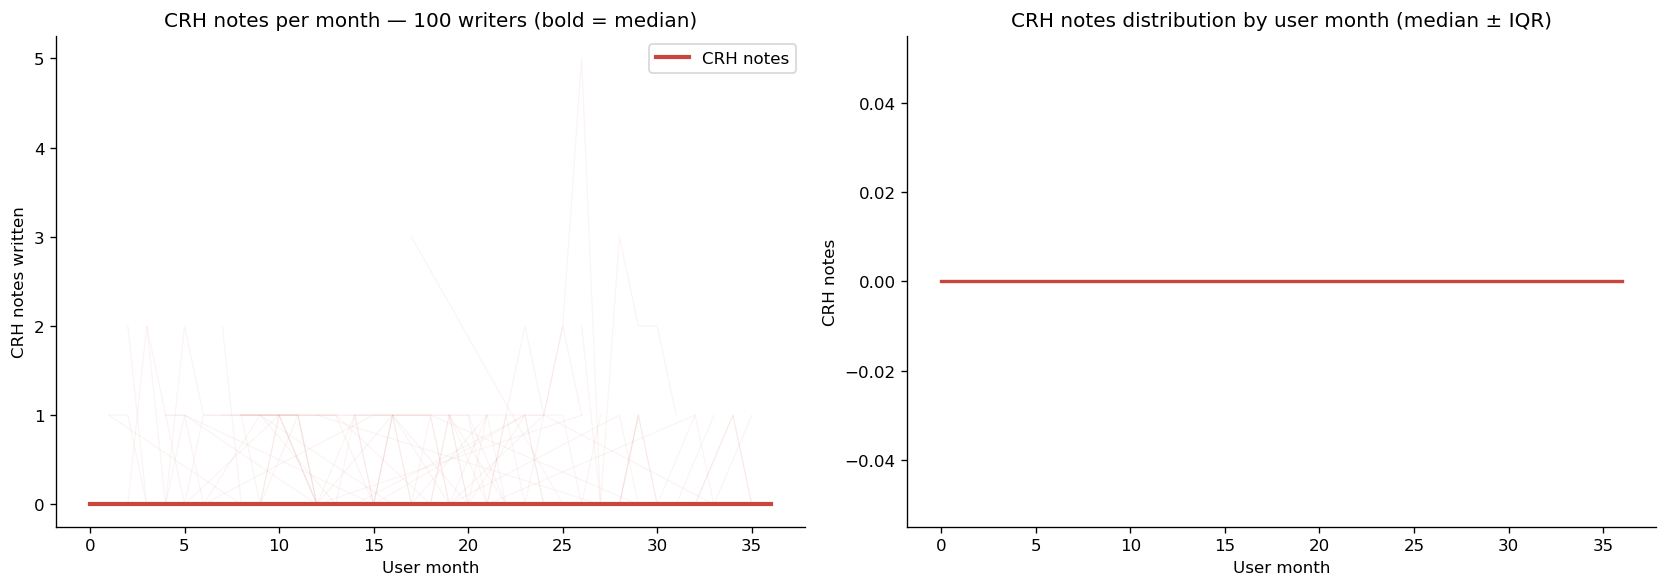

Median CRH notes by user month (first 13):
userMonth
0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
Name: hits, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
indiv_plot(ax, NOTE, 'noteAuthorParticipantId', sampled_writers, 'hits', RED, 'CRH notes')
ax.set_xlabel('User month')
ax.set_ylabel('CRH notes written')
ax.set_title(f'CRH notes per month — {SAMPLE_N} writers (bold = median)')
ax.legend()

ax = axes[1]
dist_plot(ax, NOTE, 'hits', RED)
ax.set_ylabel('CRH notes')
ax.set_title('CRH notes distribution by user month (median ± IQR)')

plt.tight_layout()
plt.savefig('task4_writer_crh.png', bbox_inches='tight')
plt.show()

sub = NOTE[NOTE['userMonth'] <= 12].dropna(subset=['hits'])
print('Median CRH notes by user month (first 13):')
print(sub.groupby('userMonth')['hits'].median().round(2))

### Requester — Requests Resulting in Notes and CRH Notes

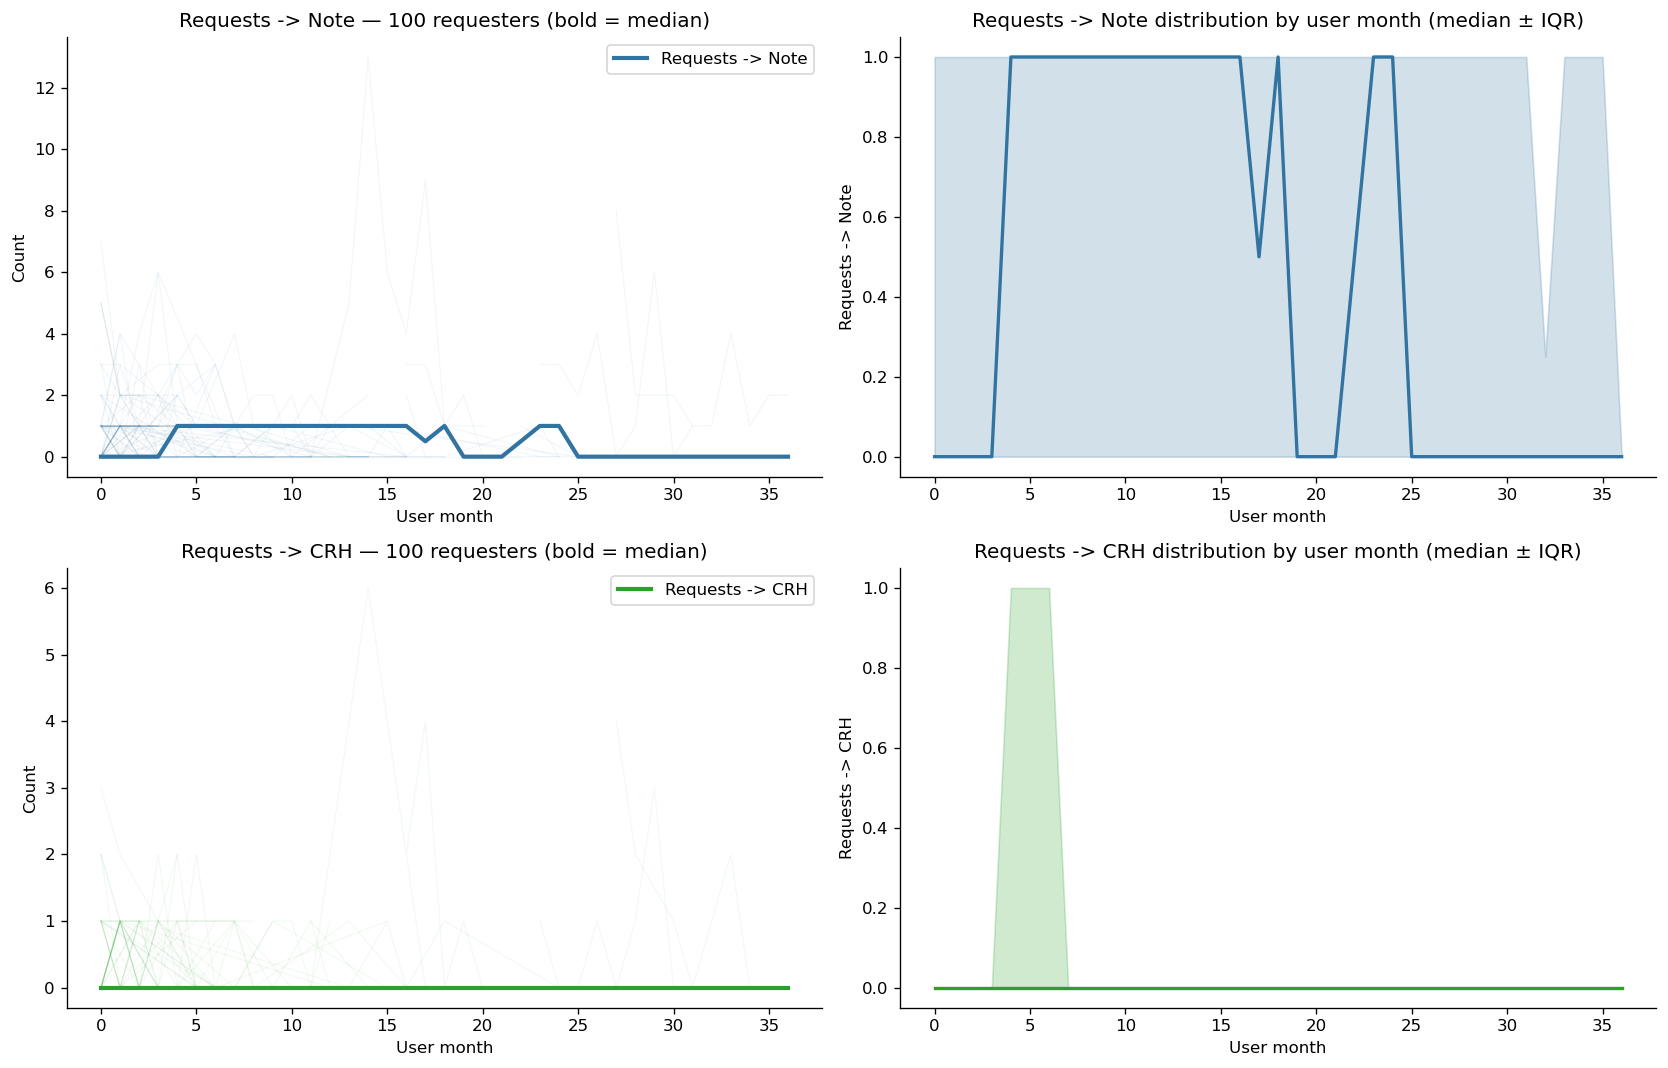

Pct requests resulting in note/CRH (median by month 0-12):
           pctRequestResultedInNote  pctRequestResultedInCrh
userMonth                                                   
0                             0.000                      0.0
1                             0.000                      0.0
2                             0.000                      0.0
3                             0.000                      0.0
4                             0.500                      0.0
5                             0.400                      0.0
6                             0.345                      0.0
7                             0.333                      0.0
8                             0.381                      0.0
9                             0.100                      0.0
10                            0.167                      0.0
11                            0.250                      0.0
12                            0.129                      0.0


In [22]:
sampled_requesters = sample_users(REQ, 'requesterParticipantId')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, (col, color, label) in enumerate([
    ('numRequestsResultingInNote', BLUE,  'Requests -> Note'),
    ('numRequestsResultingInCrh',  GREEN, 'Requests -> CRH'),
]):
    ax = axes[row, 0]
    indiv_plot(ax, REQ, 'requesterParticipantId', sampled_requesters, col, color, label)
    ax.set_xlabel('User month')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — {SAMPLE_N} requesters (bold = median)')
    ax.legend()

    ax = axes[row, 1]
    dist_plot(ax, REQ, col, color, label=label)
    ax.set_ylabel(label)
    ax.set_title(f'{label} distribution by user month (median ± IQR)')

plt.tight_layout()
plt.savefig('task4_requester.png', bbox_inches='tight')
plt.show()

sub = REQ[REQ['userMonth'] <= 12]
print('Pct requests resulting in note/CRH (median by month 0-12):')
print(sub.groupby('userMonth')[['pctRequestResultedInNote','pctRequestResultedInCrh']].median().round(3))